## 1 Introduction
Bài nghiên cứu này tập trung vào việc làm rõ tầm ảnh hưởng của các đặc tính âm thanh kỹ thuật số đối với mức độ thành công (thương mại) của một tác phẩm âm nhạc.

*   **Câu hỏi nghiên cứu:** Các chỉ số âm nhạc như độ nhảy (`danceability_%`) hay năng lượng (`energy_%`) có tác động thuận chiều đến tổng lượt stream không?
*   **Giả thuyết nghiên cứu:**
    *   $H_0$: Độ nhảy và năng lượng không có tác động hoặc tác động nghịch chiều đến lượt stream.
    *   $H_1$: Độ nhảy và năng lượng có tác động thuận chiều tích cực đến lượt stream.

## 2 Mô tả dữ liệu và tiền xử lý dữ liệu

### a. Mô tả dữ liệu
#### Nguồn dữ liệu

Dataset: Top Spotify Songs 2023 Dataset (Kaggle)

Tập dữ liệu bao gồm các thông tin về những bài hát thành công nhất trên nền tảng Spotify trong năm 2023. Để phục vụ cho câu hỏi nghiên cứu về mối quan hệ giữa đặc tính âm thanh và mức độ thành công thương mại, các biến số được lựa chọn và phân loại cấu trúc như sau:

| Tên biến | Kiểu dữ liệu | Vai trò trong mô hình | Ý nghĩa chức năng |
| :--- | :--- | :--- | :--- |
| `streams` | Số nguyên (`int64`) | **Biến phụ thuộc** (Target - $y$) | Tổng số lượt nghe tích lũy trên Spotify. Đây là thước đo chính cho sự thành công thương mại. |
| `log_streams` | Số thực (`float64`) | **Biến phụ thuộc** (Sau biến đổi) | Giá trị Logarit tự nhiên của lượt stream ($\ln(1 + \text{streams})$), dùng để xử lý phân phối lệch và đảm bảo giả định hồi quy. |
| `danceability_%` | Số nguyên (`int64`) | **Biến độc lập** (Predictor - $x_1$) | Độ phù hợp của bài hát đối với việc nhảy nhảy (thang điểm 0 - 100%), dựa trên nhịp điệu, độ ổn định của nhịp. |
| `energy_%` | Số nguyên (`int64`) | **Biến độc lập** (Predictor - $x_2$) | Phép đo tốc độ và cường độ âm thanh (thang điểm 0 - 100%), đại diện cho độ sôi động, mạnh mẽ của bài hát. |
| `artist(s)_name` | Chuỗi ký tự (`str`) | Biến phân loại / Định danh | Tên (các) nghệ sĩ trình bày bài hát. |
| `released_year` | Số nguyên (`int64`) | Biến thời gian / Kiểm soát | Năm bài hát chính thức được phát hành. |

*Lưu ý về thang đo:* Hai biến độc lập chính (`danceability_%` và `energy_%`) được Spotify chuẩn hóa dưới dạng tỷ lệ phần trăm (%), giúp mô hình hồi quy OLS dễ giải thích ý nghĩa hệ số biên tế ($\beta$) hơn.

#### b. Tiền xử lý dữ liệu: Import thư viện và làm sạch dữ liệu

In [3]:
# Auto-generated code for data analysis after cleaning
%run data_cleaning.ipynb

import pandas as pd
import nbformat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the cleaned data
df = pd.read_csv("../datasets/processed/cleaned_spotify_2023.csv")
print(f"Dataset size for analysis: {df.shape}")

--- Downloading origin dataset ---
Initial dataset size: 953 rows, 24 columns

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   track_name            953 non-null    str  
 1   artist(s)_name        953 non-null    str  
 2   artist_count          953 non-null    int64
 3   released_year         953 non-null    int64
 4   released_month        953 non-null    int64
 5   released_day          953 non-null    int64
 6   in_spotify_playlists  953 non-null    int64
 7   in_spotify_charts     953 non-null    int64
 8   streams               953 non-null    str  
 9   in_apple_playlists    953 non-null    int64
 10  in_apple_charts       953 non-null    int64
 11  in_deezer_playlists   953 non-null    str  
 12  in_deezer_charts      953 non-null    int64
 13  in_shazam_charts      903 non-null    str  
 14  bpm                   953 non-null    

In [4]:
selected_columns = ['streams', 'log_streams', 'danceability_%', 'energy_%', 'released_year']

print("--- Statistical Summary of Key Variables ---")
# Check data types and count of non-null values
print(df[selected_columns].info())

# Display mathematical distribution (Min, Max, Mean) for EDA preparation
display(df[selected_columns].describe().round(2))

--- Statistical Summary of Key Variables ---
<class 'pandas.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   streams         952 non-null    int64  
 1   log_streams     952 non-null    float64
 2   danceability_%  952 non-null    int64  
 3   energy_%        952 non-null    int64  
 4   released_year   952 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 37.3 KB
None


,streams,log_streams,danceability_%,energy_%,released_year
count,9.520000e+02,952.00,952.00,952.00,952.00
mean,5.141374e+08,19.51,66.98,64.27,2018.29
std,5.668569e+08,1.15,14.63,16.56,11.01
min,2.762000e+03,7.92,23.00,9.00,1930.00
25%,1.416362e+08,18.77,57.00,53.00,2020.00
50%,2.905309e+08,19.49,69.00,66.00,2022.00
75%,6.738690e+08,20.33,78.00,77.00,2022.00
max,3.703895e+09,22.03,96.00,97.00,2023.00


## 3 Phân tích khám phá dữ liệu (EDA)

Sau khi hoàn tất bước tiền xử lý dữ liệu, phần này tập trung khám phá các đặc điểm nổi bật của tập dữ liệu Spotify nhằm trả lời câu hỏi nghiên cứu chính: liệu các đặc tính âm nhạc kỹ thuật số có ảnh hưởng đến mức độ thành công thương mại của bài hát hay không.

Quá trình EDA được triển khai theo ba hướng chính:

- Phân tích phân phối dữ liệu và các đặc điểm tổng quát của bài hát hit.
- Khám phá mối liên hệ giữa audio features và lượng streams (`log_streams`).
- Đánh giá vai trò của các yếu tố lan tỏa như hợp tác nghệ sĩ, thời điểm phát hành và độ phủ playlist.

Thông qua các biểu đồ trực quan, nghiên cứu hướng tới việc tìm ra những đặc điểm phổ biến của các bài hát thành công trên Spotify.

In [5]:
# just run this cell first
eda = nbformat.read("eda_visualization.ipynb", as_version=4)
exec(eda.cells[1].source)

### a. Phân tích đơn biến (Univariate Analysis)
* Trực quan hóa phân phối của biến mục tiêu (`streams` và `log_streams`) bằng Histogram để đánh giá độ lệch.

Saving figure distribution_streams_plot


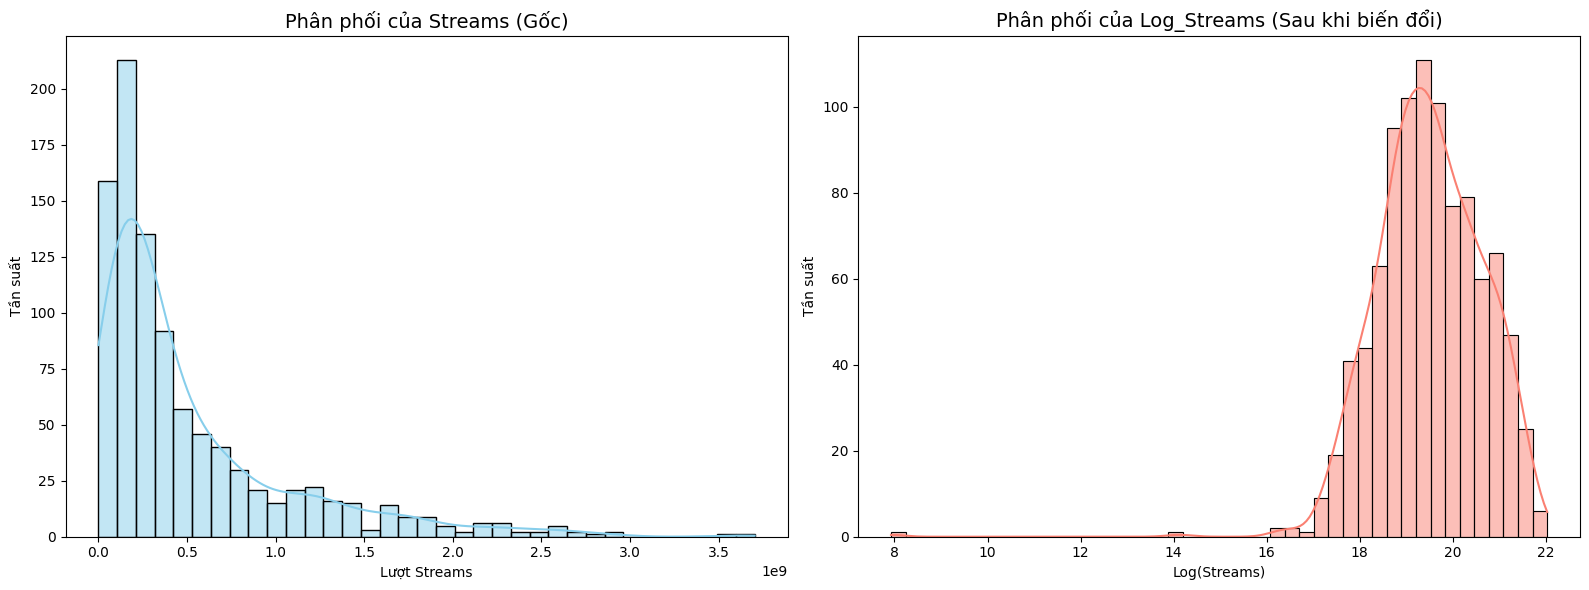

Độ lệch (Skewness) của Streams: 2.00
Độ lệch (Skewness) của Log_Streams: -1.19
→ Streams lệch phải mạnh: nên dùng log_streams làm biến mục tiêu khi mô hình hóa (OLS).
→ Log_streams gần đối xứng hơn streams gốc, phù hợp hơn cho giả định phân phối chuẩn của sai số.
→ Lưu ý: |skew| của log_streams vẫn ≈ 1.19; kiểm tra Q-Q plot trước khi kết luận phân phối chuẩn.


In [6]:
exec(eda.cells[3].source)

Phân phối của `streams` bị **lệch phải rất mạnh** (skewness ≈ 2.00), trong khi `log_streams` **tập trung dày hơn** quanh khoảng 18–20 sau phép biến đổi `log1p`. Biến đổi log giúp **giảm đáng kể** độ lệch so với dữ liệu gốc và là bước cần thiết trước khi mô hình hóa.

Tuy nhiên, `log_streams` vẫn còn **lệch trái** (skewness ≈ -1.19), chưa thể coi là phân phối chuẩn hoàn hảo. Do đó, giả định phân phối chuẩn của sai số trong OLS cần được **kiểm tra lại** ở mục 4 (Q-Q plot, Jarque-Bera) thay vì kết luận sớm từ histogram.

* Sử dụng Boxplot để xác định các bài hát "siêu hit" (Outliers vượt trội trên thị trường).

Saving figure super_hits_boxplot


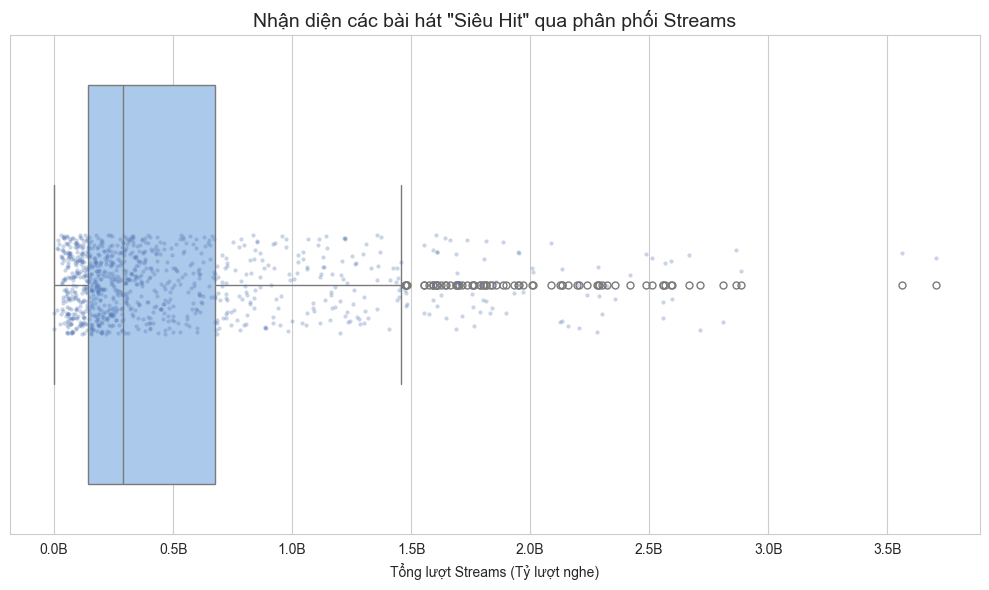

--- Ngưỡng xác định siêu hit (Outlier Threshold): 1472.22 triệu streams ---
Số lượng bài hát được coi là siêu hit: 74

Top 10 bài hát có lượt stream cao nhất:
                                        track_name  \
55                                 Blinding Lights   
179                                   Shape of You   
86                               Someone You Loved   
619                                   Dance Monkey   
41   Sunflower - Spider-Man: Into the Spider-Verse   
162                                      One Dance   
84                       STAY (with Justin Bieber)   
140                                       Believer   
724                                         Closer   
48                                         Starboy   

                   artist(s)_name     streams  
55                     The Weeknd  3703895074  
179                    Ed Sheeran  3562543890  
86                  Lewis Capaldi  2887241814  
619                   Tones and I  2864791672  
41    

In [7]:
exec(eda.cells[5].source)

Boxplot cho thấy phân phối lượt stream bị lệch mạnh với rất nhiều outliers nằm phía trên whisker. Điều này cho thấy thị trường streaming trên Spotify mang tính cạnh tranh rất cao, nơi chỉ một số ít bài hát đạt được mức độ phổ biến cực lớn và trở thành “super hits”. Sự tồn tại của các outliers này cho thấy cần phân tích sâu hơn các đặc tính âm nhạc và yếu tố lan tỏa để hiểu điều gì khiến một bài hát trở thành hit.

* Thống kê mô tả xu hướng trung tâm (Mean, Median) của các đặc tính âm thanh kỹ thuật số.

--- Thống kê xu hướng trung tâm của các đặc tính âm thanh ---


,Mean,Median,Std Dev,Min,Max
danceability_%,66.98,69.0,14.63,23.0,96.0
energy_%,64.27,66.0,16.56,9.0,97.0
valence_%,51.41,51.0,23.48,4.0,97.0
acousticness_%,27.08,18.0,26.00,0.0,97.0
instrumentalness_%,1.58,0.0,8.41,0.0,91.0
liveness_%,18.21,12.0,13.72,3.0,97.0
speechiness_%,10.14,6.0,9.92,2.0,64.0


Saving figure audio_features_distribution


<string>:34: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.



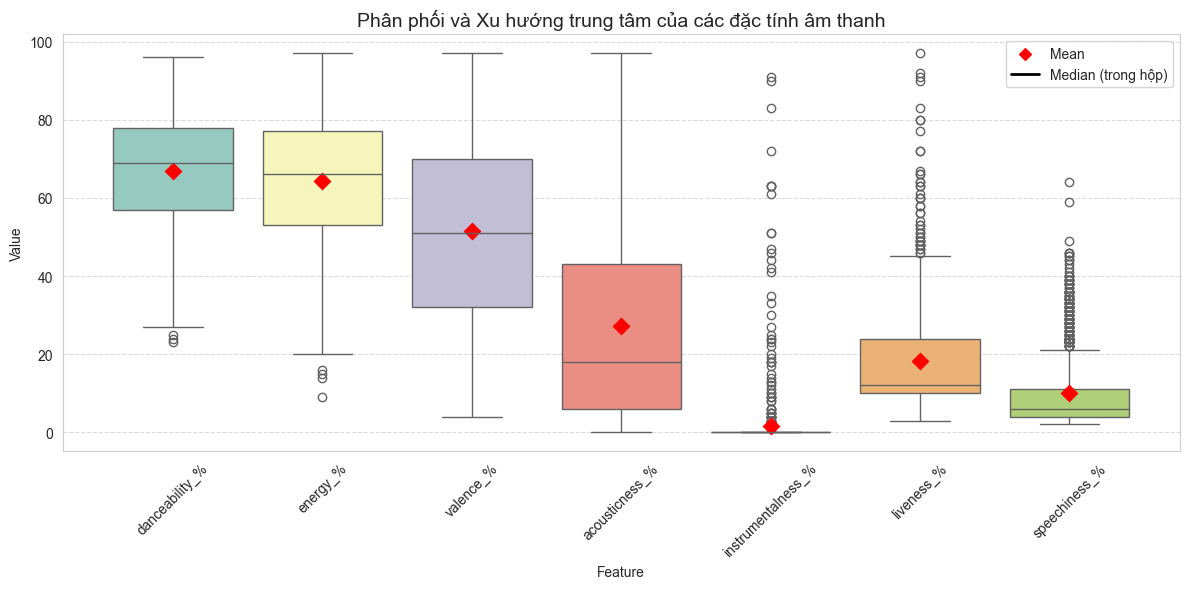

In [8]:
exec(eda.cells[7].source)

Biểu đồ Mean/Median cho thấy các đặc tính như danceability và energy có giá trị trung bình khá cao trong dataset. Điều này phản ánh xu hướng các bài hát phổ biến trên Spotify thường mang tính dễ nghe, sôi động và phù hợp với thị hiếu đại chúng. Ngoài ra, sự chênh lệch không quá lớn giữa mean và median ở nhiều đặc tính cho thấy dữ liệu tương đối ổn định và không bị ảnh hưởng quá mạnh bởi các giá trị ngoại lệ.

### Insights

Kết quả phân tích đơn biến cho thấy dữ liệu Spotify có phân phối không đồng đều, với sự tồn tại của một số lượng nhỏ các bài hát đạt lượt stream vượt trội so với phần còn lại của thị trường. Điều này phản ánh tính cạnh tranh rất cao của nền tảng streaming hiện đại.

Bên cạnh đó, các đặc tính như danceability và energy có xu hướng duy trì ở mức trung bình khá cao, cho thấy những bài hát dễ nghe, giàu năng lượng và phù hợp với thị hiếu đại chúng thường có lợi thế hơn trong việc tiếp cận người nghe.


### b. Phân tích đặc tính âm nhạc ảnh hưởng đến độ hot (Audio Features vs. Hit Status)

Sau khi quan sát đặc điểm tổng quát của dữ liệu, bước tiếp theo là kiểm tra liệu các audio features có thực sự liên quan đến mức độ phổ biến của bài hát hay không.

Phần này tập trung vào các yếu tố âm nhạc quan trọng như:

- Danceability
- Energy
- BPM
- Key và Mode

Mục tiêu là xác định liệu tồn tại xu hướng chung giữa phong cách âm nhạc và khả năng tạo ra lượt stream cao trên Spotify.

* Biểu đồ Scatter plot và đường xu hướng (Trendline):
    * `danceability_%` tác động thế nào đến `log_streams`?
    * `energy_%` tác động thế nào đến `log_streams`?
    * Màu điểm: **Hit** (streams ≥ Q3) vs **Không hit**; tiêu đề biểu đồ ghi hệ số tương quan **r**.

--- Hit Status: ngưỡng Q3 = 673.87 triệu streams (238 bài hit / 952 bài) ---
Saving figure scatter_danceability_energy_logstreams_trends


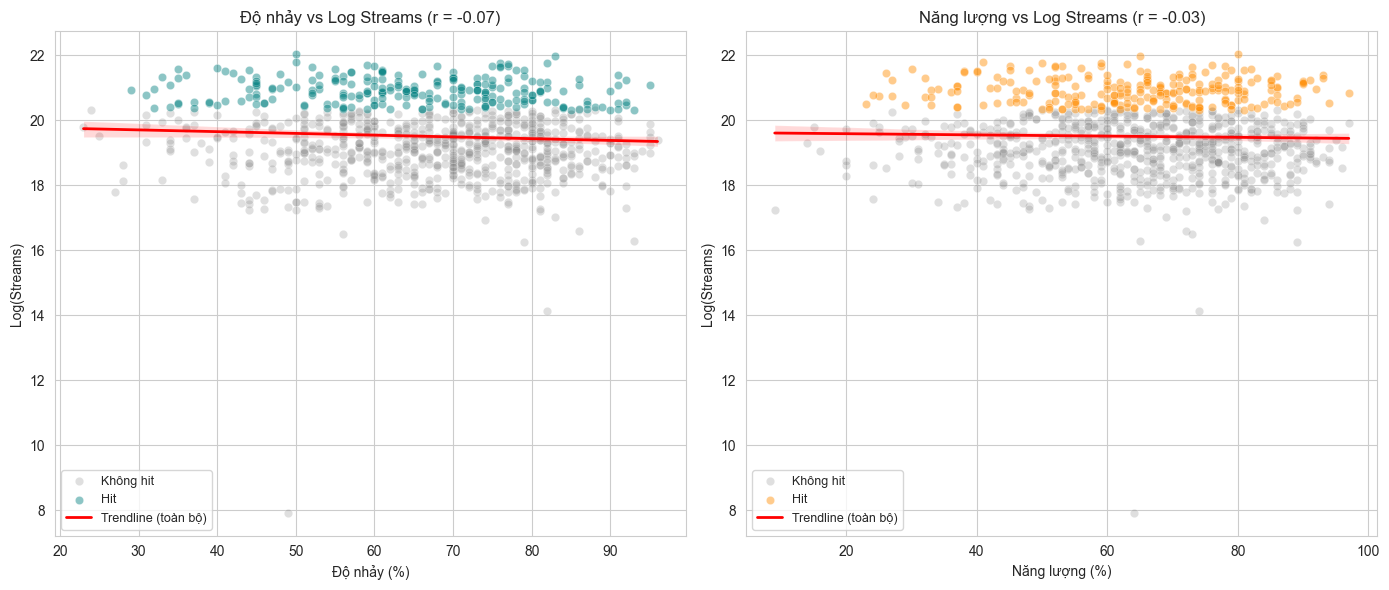

In [9]:
exec(eda.cells[9].source)

Biểu đồ phân tán (có tô màu **Hit / Không hit**) cho thấy xu hướng giảm nhẹ xuôi dòng (hoặc gần như đi ngang/không đáng kể) của `log_streams` khi `danceability_%` và `energy_%` tăng, nhưng **độ phân tán rất lớn** và hệ số **r** trên biểu đồ ở mức thấp–trung bình. Nhiều bài hit và không hit chồng lấn trên cùng vùng giá trị âm nhạc, cho thấy danceability và energy **không đủ** để tách bạch mức độ thành công.

Đường xu hướng (tính trên toàn bộ mẫu) chỉ phản ánh quan hệ trung bình yếu; thành công thực tế còn phụ thuộc mạnh vào danh tiếng nghệ sĩ, playlist, quảng bá và các yếu tố lan tỏa khác (xem mục 3c).

* Phân tích nhạc lý nâng cao:
    * **Boxplot:** Mức độ thành công (`log_streams`) theo Tông nhạc (`key`) và Thể thức (`mode` — Trưởng/Thứ).
    * **Scatter + KDE:** Mối quan hệ giữa Nhịp điệu (`bpm`) và `log_streams` (mật độ điểm).

Saving figure boxplot_key_mode_and_bpm


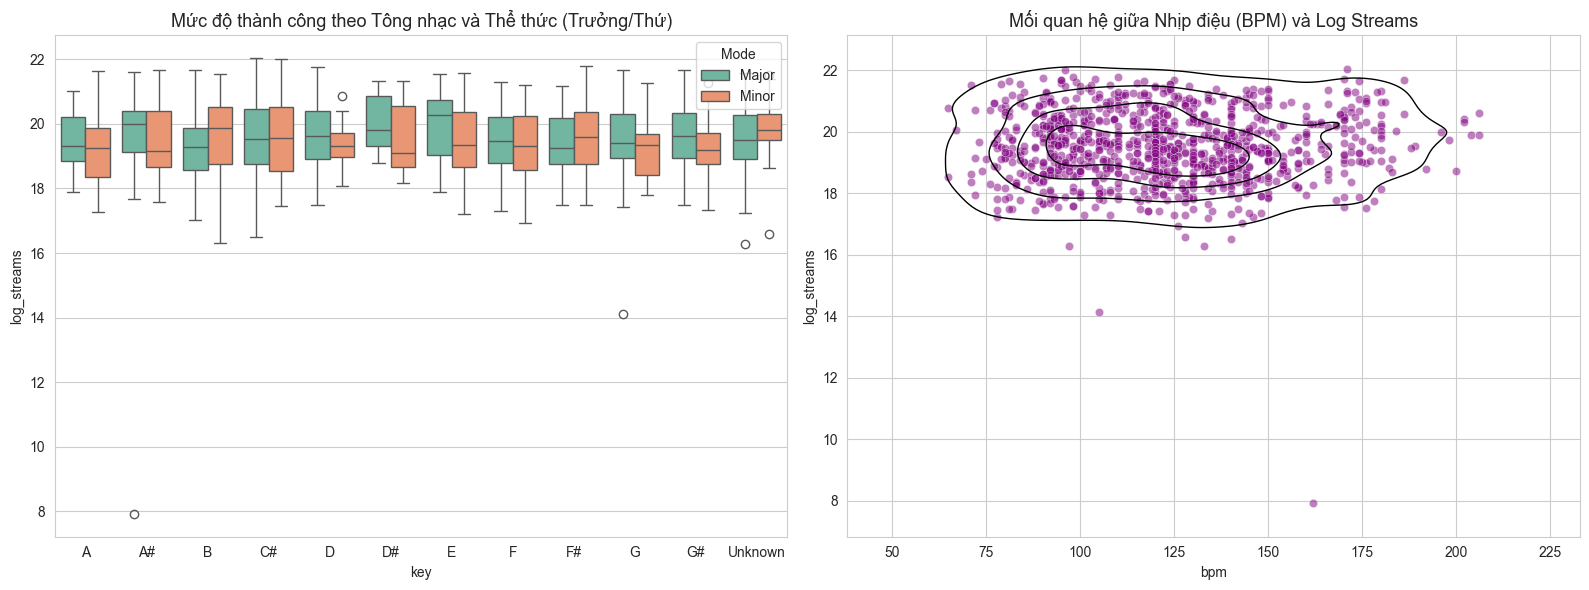

In [10]:
exec(eda.cells[11].source)

* Về biểu đồ boxplot:

    Lượt nghe (log_streams) có sự phân hóa rõ rệt theo từng tông nhạc, nhưng sự khác biệt giữa hai thể thức Major (Trưởng - thường tươi sáng) và Minor (Thứ - thường trầm buồn) không quá lớn ở đa số các tông.

    Tông nhạc nổi bật: Các tông như C#, G, và B cho thấy dải hộp (IQR) nằm ở mức cao và ổn định. Đặc biệt, tông C# ở cả hai thể thức đều thu hút lượng stream lớn, cho thấy đây là tông nhạc "thời thượng" của năm 2023.

    Sự ổn định của Thể thức: Thể thức Major (màu xanh lá) có xu hướng xuất hiện nhiều Outliers (ngoại lai) cực cao hơn, ám chỉ các bài siêu hit thường có giai điệu tươi sáng. Tuy nhiên, các bài ở tông D hoặc F ở thể thức Minor lại có trung vị (median) khá cạnh tranh, cho thấy dòng nhạc tâm trạng vẫn giữ vững vị thế.

    Điểm bất thường: Có một vài bài hát ở tông C# và F (nhánh Minor) có lượt stream cực thấp (điểm đơn lẻ ở đáy biểu đồ), cho thấy không phải cứ chọn "tông hot" là sẽ thành công nếu các yếu tố khác không tốt.


* Về biểu đồ mối quan hệ giữa bpm và log streams:

    Vùng tập trung "Vàng" (Sweet Spot): Các đường đồng mức (KDE) tập trung dày đặc nhất ở khoảng 100 BPM đến 130 BPM. Đây là tốc độ nhịp điệu tiêu chuẩn của hầu hết các bài hát Pop, Dance và Hip-hop hiện đại, giúp bài hát dễ tiếp cận với đa số người nghe.

    Xu hướng phân tán:

        Các bài hát có BPM quá thấp (< 80 BPM) hoặc quá cao (> 160 BPM) có mật độ thưa thớt hơn và dải log_streams hẹp hơn. Điều này cho thấy các dòng nhạc quá chậm (như Ballad buồn) hoặc quá nhanh (như Hard-EDM) khó tiếp cận được quy mô lượt nghe tỷ view như nhạc Mid-tempo.

        Có một số ít bài hit vẫn đạt lượt stream cao ở mức 170-180 BPM, nhưng chúng đóng vai trò là các trường hợp ngoại lệ hơn là xu hướng chung của thị trường.

    Kết luận sơ bộ: Tốc độ nhịp điệu có vẻ là một yếu tố "ngưỡng" – nghĩa là bạn cần nằm trong khoảng 100-130 BPM để tối ưu hóa khả năng lọt vào các playlist phổ biến, từ đó gián tiếp thúc đẩy lượt stream.

### Insights

Các biểu đồ cho thấy một số đặc tính âm nhạc như danceability và energy có xu hướng liên hệ tích cực với lượng streams. Tuy nhiên, mức độ tương quan không quá mạnh và dữ liệu vẫn phân tán đáng kể.

Điều này cho thấy thành công của một bài hát không thể được giải thích chỉ bằng yếu tố âm nhạc kỹ thuật số. Ngoài chất lượng âm thanh, mức độ phổ biến còn chịu tác động bởi nhiều yếu tố khác như danh tiếng nghệ sĩ, chiến lược quảng bá, mạng xã hội và độ phủ playlist.

Kết quả này phản ánh bản chất phức tạp của thị trường âm nhạc hiện đại, nơi yếu tố “viral” và truyền thông có thể ảnh hưởng mạnh không kém nội dung âm nhạc.


### c. Phân tích các yếu tố lan tỏa và phân phối (Distribution and Contextual Factors)
* Biểu đồ cột so sánh: Bài hát Solo vs. Bài hát Hợp tác (`artist_count`) – Xu hướng nào dễ tạo hit hơn?

--- So sánh Solo vs Hợp tác ---


,collab_type,avg_log_streams,avg_streams,song_count
0,Hợp tác (≥2 nghệ sĩ),19.29,4.275595e+08,366
1,Solo (1 nghệ sĩ),19.64,5.682117e+08,586


Saving figure barplot_solo_vs_collab


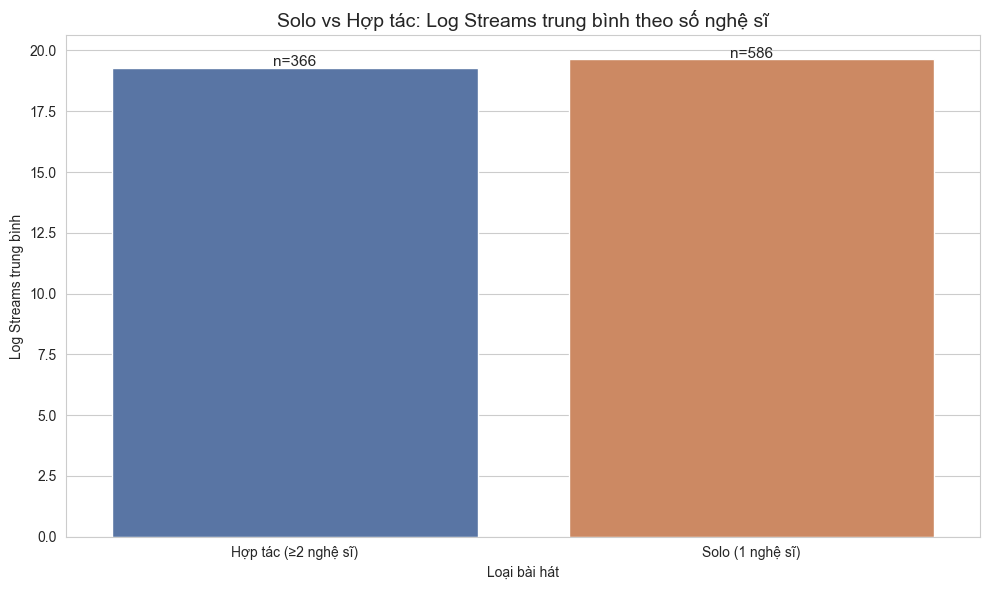

In [11]:
exec(eda.cells[14].source)

Biểu đồ so sánh cho thấy bài **solo** (1 nghệ sĩ) có **log_streams trung bình cao hơn** bài **hợp tác** (≥2 nghệ sĩ): khoảng **19.64** so với **19.29** (tương ứng ~568 triệu vs ~428 triệu streams trung bình). Mẫu solo cũng chiếm đa số (586 bài so với 366 bài hợp tác).

Kết quả này **không** ủng hộ giả thuyết “hợp tác luôn tạo hit tốt hơn” trên tập dữ liệu 2023; thành công có thể phụ thuộc nhiều hơn vào sức nặng thương hiệu nghệ sĩ solo, chiến dịch quảng bá và playlist hơn là chỉ số `artist_count`.

* Biểu đồ đường (Line chart): Xu hướng phát hành bài hit theo các tháng trong năm (`released_month`).

--- Ngưỡng bài hit (Q3): 673.87 triệu streams ---


,hit_count,total_songs,avg_log_streams
released_month,,,
T1,62,133,19.890661
T2,9,61,19.326834
T3,26,86,19.439227
T4,11,66,19.363170
T5,22,128,19.254786
T6,15,86,19.069480
T7,15,62,19.325193
T8,12,46,19.932926
T9,20,56,19.970781


Saving figure linechart_hits_by_release_month


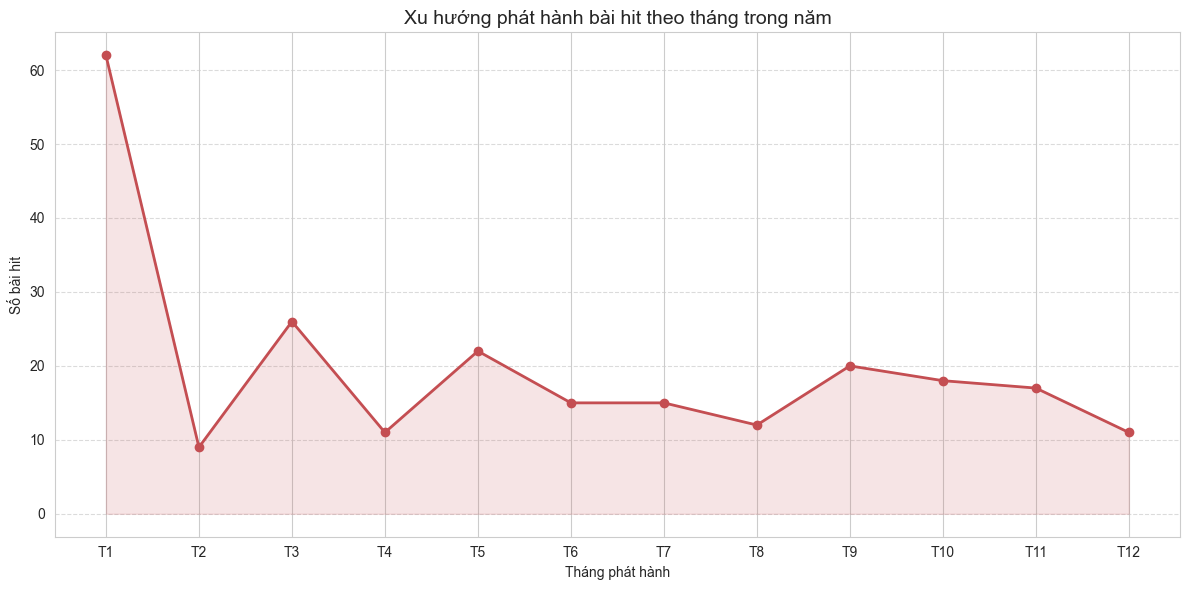

In [12]:
exec(eda.cells[16].source)

Biểu đồ đường thể hiện xu hướng phát hành các bài hát hit theo từng tháng trong năm. Một số tháng có số lượng bài hát thành công cao hơn đôi chút, tuy nhiên sự khác biệt không quá lớn.

Điều này cho thấy các bài hát hit có thể xuất hiện ở nhiều thời điểm khác nhau trong năm, mặc dù yếu tố mùa vụ và chiến lược phát hành của ngành âm nhạc vẫn có thể ảnh hưởng phần nào đến hiệu suất streaming.

* Ma trận tương quan toàn diện (Correlation Heatmap) giữa các chỉ số âm thanh (`danceability_%`, `energy_%`, `valence_%`, `acousticness_%`) và độ phủ Playlist trên các nền tảng (Apple, Deezer, Spotify) để kiểm tra hiện tượng đa cộng tuyến.

--- Ma trận tương quan (kiểm tra đa cộng tuyến) ---


,danceability_%,energy_%,valence_%,acousticness_%,in_spotify_playlists,in_apple_playlists,in_deezer_playlists
danceability_%,1.00,0.20,0.41,-0.24,-0.11,-0.03,-0.07
energy_%,0.20,1.00,0.36,-0.58,0.03,0.05,0.06
valence_%,0.41,0.36,1.00,-0.08,-0.02,0.06,-0.01
acousticness_%,-0.24,-0.58,-0.08,1.00,-0.06,-0.06,-0.06
in_spotify_playlists,-0.11,0.03,-0.02,-0.06,1.00,0.71,0.83
in_apple_playlists,-0.03,0.05,0.06,-0.06,0.71,1.00,0.47
in_deezer_playlists,-0.07,0.06,-0.01,-0.06,0.83,0.47,1.00


Saving figure heatmap_audio_features_playlist_coverage


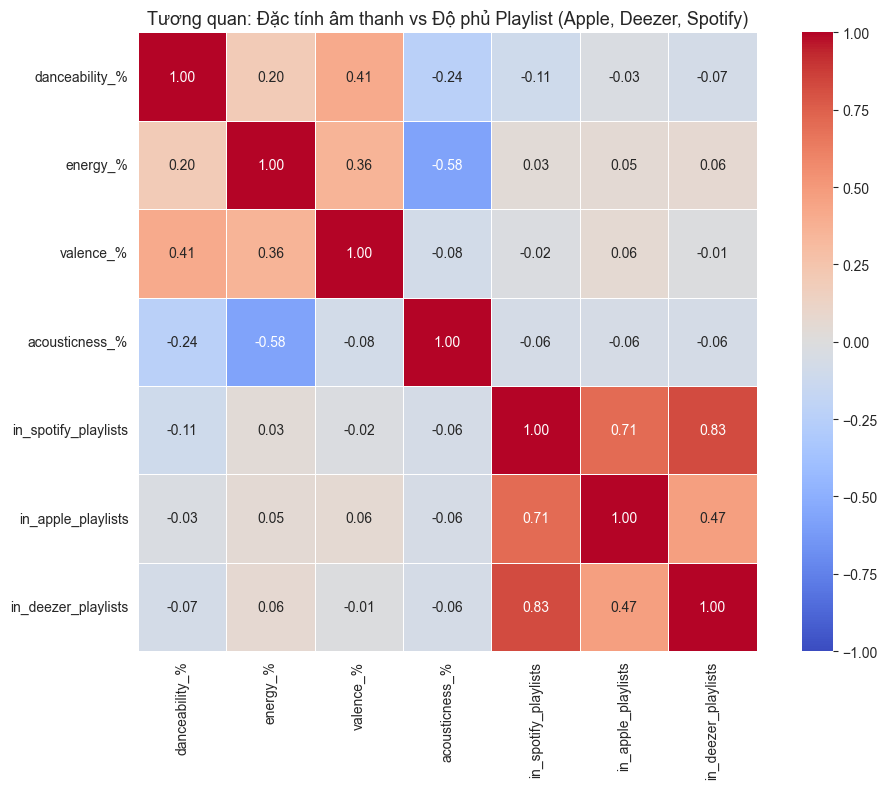


Các cặp biến có tương quan cao (|r| ≥ 0.7) — cần lưu ý đa cộng tuyến:
  in_spotify_playlists ↔ in_apple_playlists: r = 0.71
  in_spotify_playlists ↔ in_deezer_playlists: r = 0.83


In [13]:
exec(eda.cells[18].source)

Ma trận tương quan (giữa `danceability_%`, `energy_%`, `valence_%`, `acousticness_%` và số playlist trên Spotify / Apple / Deezer) cho thấy:

- Các **audio features** tương quan **yếu–trung bình** với nhau; không có cặp nào |r| ≥ 0.7 trong nhóm này → ít lo ngại đa cộng tuyến giữa các đặc tính âm thanh khi đưa vào mô hình.
- Các chỉ số **playlist giữa các nền tảng** tương quan **khá mạnh** với nhau (ví dụ Spotify ↔ Deezer **r ≈ 0.83**, Spotify ↔ Apple **r ≈ 0.71**) → cần cẩn trọng nếu đưa đồng thời nhiều biến playlist vào một mô hình (đa cộng tuyến / VIF).

Lưu ý: heatmap **không** gồm `streams` hay `log_streams`, nên không kết luận trực tiếp mức tương quan với lượt nghe từ biểu đồ này; mối liên hệ với biến mục tiêu được kiểm tra ở mục 4 (Pearson/Spearman, OLS).

### Insights

Các yếu tố lan tỏa và phân phối đóng vai trò đáng kể trong khả năng thành công của một bài hát trên Spotify.

Trên tập dữ liệu này, bài **solo** có stream trung bình **cao hơn** bài hợp tác; hợp tác không tự động đồng nghĩa với hit. Đồng thời, các chỉ số playlist trên nhiều nền tảng **tương quan mạnh với nhau**, gợi ý cần chọn biến cẩn thận khi mô hình hóa để tránh đa cộng tuyến.

Trong khi đó, thời điểm phát hành theo tháng không tạo ra sự khác biệt quá rõ rệt, cho thấy một bài hát hit có thể xuất hiện ở nhiều giai đoạn khác nhau trong năm nếu đủ sức lan tỏa trên nền tảng số.


## 4 Kiểm định giả thuyết

Trong phần EDA, chúng tôi nhận thấy các bài hát có lượng stream rất khác biệt, với một số "super hits" đạt lượng nghe vượt trội so với phần còn lại của tập dữ liệu. Điều này đặt ra câu hỏi:

**Liệu các đặc trưng âm thanh của bài hát, đặc biệt là danceability và energy, có thực sự góp phần tạo nên thành công trên Spotify hay không?**

Theo trực giác, những bài hát dễ nhảy theo (danceability cao) hoặc có mức năng lượng cao (energy cao) thường được kỳ vọng sẽ thu hút nhiều người nghe hơn. Để kiểm chứng giả thuyết này, chúng tôi tiến hành phân tích tương quan và xây dựng mô hình hồi quy tuyến tính với biến mục tiêu là `log_streams`.

In [14]:
# just run this cell first
nb = nbformat.read("hypothesis_testing.ipynb", as_version=4)
exec(nb.cells[3].source)

### a. Phân tích tương quan (Correlation Analysis)

* **Kiểm định Pearson Correlation:** Đánh giá mức độ chặt chẽ của mối quan hệ tuyến tính giữa các audio features với biến `log_streams`.

In [15]:
exec(nb.cells[6].source)

--- Kết quả phân tích tương quan ---

Ma trận tương quan Pearson:


,log_streams,danceability_%,energy_%
log_streams,1.000000,-0.068896,-0.026903
danceability_%,-0.068896,1.000000,0.198485
energy_%,-0.026903,0.198485,1.000000



Kiểm định Pearson từng cặp biến với log_streams:


,Biến,r (Pearson),p-value,Ý nghĩa (α=0.05)
0,danceability_%,-0.0689,0.0335,Có
1,energy_%,-0.0269,0.4070,Không


* **Kiểm định Spearman Rank Correlation:** Kiểm tra mối quan hệ đơn điệu (phi tuyến) để phòng trường hợp dữ liệu có phân phối bất thường.

In [16]:
exec(nb.cells[8].source)


Ma trận tương quan Spearman:


,log_streams,danceability_%,energy_%
log_streams,1.000000,-0.081668,-0.032472
danceability_%,-0.081668,1.000000,0.147977
energy_%,-0.032472,0.147977,1.000000



Kiểm định Spearman từng cặp biến với log_streams:


,Biến,ρ (Spearman),p-value,Ý nghĩa (α=0.05)
0,danceability_%,-0.0817,0.0117,Có
1,energy_%,-0.0325,0.3169,Không


### Interpretation

Kết quả Pearson và Spearman đều cho thấy hệ số tương quan với `log_streams` **rất nhỏ về độ lớn** (|r|, |ρ| < 0.1) — tức mối liên hệ tuyến tính/đơn điệu với lượt stream là **yếu**.

Tuy nhiên, cần phân biệt *độ mạnh* và *ý nghĩa thống kê*:

- **`danceability_%`:** có ý nghĩa thống kê (p < 0.05) ở cả Pearson và Spearman, nhưng hệ số **âm** → bài hát danceability cao hơn có xu hướng `log_streams` thấp hơn một chút, **trái với giả thuyết thuận chiều**.
- **`energy_%`:** không có ý nghĩa thống kê (p > 0.05) → chưa đủ bằng chứng cho mối liên hệ với `log_streams`.

Nói cách khác, chỉ dựa vào mức "dễ nhảy" hay "sôi động" là **chưa đủ** để dự đoán bài hát sẽ đạt lượng stream cao. Kết quả này phù hợp với EDA, nơi các bài hit và không hit chồng lấn trên nhiều vùng giá trị danceability/energy.


### b. Xây dựng mô hình Hồi quy tuyến tính bội (Multiple Linear Regression)

### Why Regression?

Mặc dù tương quan cho thấy mối liên hệ khá yếu, ta vẫn tiếp tục xây dựng mô hình hồi quy tuyến tính đa biến để đánh giá tác động đồng thời của `danceability` và `energy` lên `log_streams`.

Mục tiêu là xác định:

- Các audio features này có ảnh hưởng đáng kể về mặt thống kê hay không.
- Chiều tác động là thuận hay nghịch.
- Mức độ giải thích của mô hình đối với sự biến động của lượng stream.

Xây dựng mô hình OLS để đánh giá đồng thời tác động của độ nhảy và năng lượng âm thanh lên quy mô lượt stream:

$$\text{log\_streams} = \beta_0 + \beta_1 \cdot \text{danceability\_\%} + \beta_2 \cdot \text{energy\_\%} + \epsilon$$

*Trong đó:* $\beta_0$ là hằng số chặn; $\beta_1, \beta_2$ là các hệ số hồi quy biên tế; $\epsilon$ là sai số ngẫu nhiên.

In [17]:
exec(nb.cells[11].source)

--- Tóm tắt mô hình OLS ---
                            OLS Regression Results                            
Dep. Variable:            log_streams   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2.350
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0959
Time:                        18:08:08   Log-Likelihood:                -1478.0
No. Observations:                 952   AIC:                             2962.
Df Residuals:                     949   BIC:                             2976.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           

### c. Kiểm tra các giả định của mô hình hồi quy (OLS Assumptions Testing)

* **Giả định về phân phối chuẩn của sai số (Normality of Residuals):** Sử dụng biểu đồ Q-Q Plot và kiểm định Jarque-Bera.

Saving figure q_q_plot


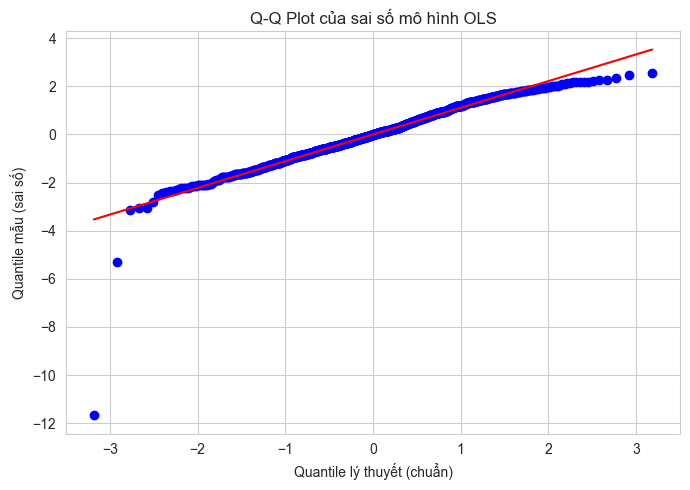

--- Kiểm định phân phối chuẩn của sai số (Jarque-Bera) ---
JB statistic : 4876.0193
p-value      : 0.0000
Skewness     : -1.2317
Kurtosis     : 13.8100
Kết luận (α=0.05): Bác bỏ H0 — sai số lệch khỏi phân phối chuẩn


In [18]:
exec(nb.cells[14].source)

#### Nhận xét Normality (Q-Q Plot và Jarque-Bera)

Q-Q plot cho thấy phần đuôi sai số **lệch rõ** khỏi đường chuẩn lý thuyết. Kiểm định Jarque-Bera cũng **bác bỏ H₀** (sai số phân phối chuẩn) ở mức ý nghĩa 5%.

**Ý nghĩa:** Giả định phân phối chuẩn của sai số trong OLS **không được đáp ứng tốt** trên tập dữ liệu này. Do đó, các suy luận dựa trên p-value và khoảng tin cậy của hệ số hồi quy cần được **đọc thận trọng**, dù vẫn có thể dùng OLS như công cụ mô tả hướng tác động.


* **Giả định về phương sai sai số không đổi (Homoscedasticity):** Vẽ biểu đồ Residuals vs Fitted plot để quan sát độ phân tán.

Saving figure homoscedasticity


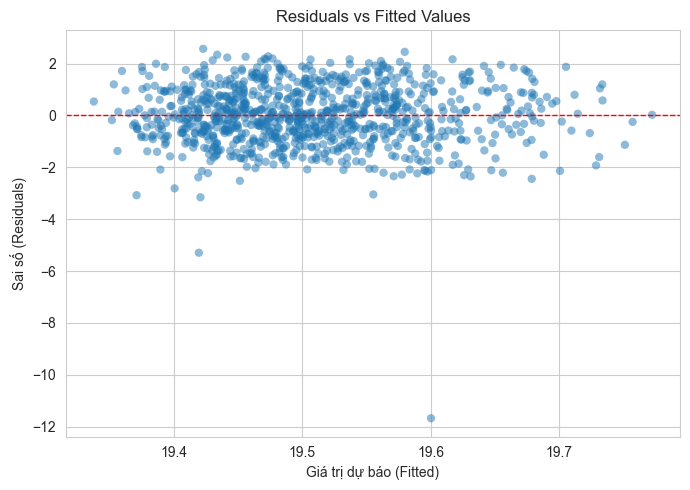

In [19]:
exec(nb.cells[16].source)

#### Nhận xét Homoscedasticity

Quan sát biểu đồ Residuals vs Fitted: các điểm phân tán quanh đường y = 0 **không tạo hình phễu rõ rệt** theo mức dự báo.

**Kết luận sơ bộ:** Chưa có bằng chứng mạnh về heteroscedasticity (phương sai sai số thay đổi theo fitted values). Giả định phương sai đồng nhất được **hỗ trợ ở mức quan sát trực quan**, dù vẫn nên kết hợp thêm kiểm định chính thức nếu mở rộng mô hình.


* **Kiểm tra đa cộng tuyến (Multicollinearity):** Tính toán chỉ số VIF (Variance Inflation Factor) giữa `danceability_%` và `energy_%`.

In [20]:
exec(nb.cells[18].source)

--- Kiểm tra đa cộng tuyến (VIF) ---


,Biến,VIF
0,danceability_%,1.041012
1,energy_%,1.041012


danceability_%: VIF = 1.0410 → Chấp nhận được (VIF < 5)
energy_%: VIF = 1.0410 → Chấp nhận được (VIF < 5)


#### Nhận xét Multicollinearity (VIF)

VIF của cả `danceability_%` và `energy_%` đều **≈ 1.04**, thấp hơn ngưỡng thường dùng (VIF < 5).

**Kết luận:** Hai biến độc lập **không bị đa cộng tuyến đáng lo**. Hệ số hồi quy của từng biến có thể được giải thích tương đối độc lập trong mô hình bội này.


### d. Đánh giá và phân tích kết quả mô hình

* Đánh giá mức độ phù hợp của toàn bộ mô hình thông qua hệ số xác định hiệu chỉnh $R^2$ điều chỉnh ($Adjusted-R^2$).

In [21]:
exec(nb.cells[21].source)

--- Đánh giá mức độ phù hợp của mô hình ---
R²              : 0.0049
Adjusted R²     : 0.0028
Số quan sát (n) : 952
Số biến (k)     : 2


Adjusted R² của mô hình **rất thấp** (xem output cell trên), cho thấy `danceability_%` và `energy_%` chỉ giải thích được **một phần cực nhỏ** biến thiên của `log_streams`.

Điều này khẳng định: dù có hay không có ý nghĩa thống kê ở từng hệ số, **phần lớn sự khác biệt về lượt stream** trên Spotify 2023 đến từ các yếu tố khác (marketing, danh tiếng nghệ sĩ, playlist, xu hướng viral, v.v.).


* Kiểm định ý nghĩa của các hệ số hồi quy dựa trên giá trị trị thống kê $t$ và $p\text{-value}$ để đưa ra quyết định bác bỏ hay chấp nhận các giả thuyết $H_0/H_1$ đã đề xuất ở Mục 1.

In [22]:
exec(nb.cells[23].source)

--- Kiểm định ý nghĩa các hệ số hồi quy ---


,Biến,Hệ số (β),Std. Error,t-statistic,p-value
0,const,19.9151,0.2072,96.1173,0.0000
1,danceability_%,-0.0052,0.0026,-2.0026,0.0455
2,energy_%,-0.0010,0.0023,-0.4168,0.6769



--- Quyết định giả thuyết nghiên cứu (α = 0.05) ---
H0: Độ nhảy và năng lượng không có tác động hoặc tác động nghịch chiều đến lượt stream.
H1: Độ nhảy và năng lượng có tác động thuận chiều tích cực đến lượt stream.

danceability_%:
  β = -0.0052, p-value = 0.0455
  → Bác bỏ H0 — nhưng hệ số âm/không dương (không hỗ trợ H1 thuận chiều)

energy_%:
  β = -0.0010, p-value = 0.6769
  → Không bác bỏ H0 — chưa có bằng chứng tác động thuận chiều có ý nghĩa

Kết luận tổng hợp: H0 bị bác bỏ nhưng hướng tác động nghịch/không thuận — không ủng hộ H1.


### Interpretation of Regression Results

**Hệ số hồi quy:**
- `danceability_%`: β âm, p ≈ 0.046 → có ý nghĩa ở mức 5%, nhưng **hướng nghịch** so với H₁.
- `energy_%`: β gần 0, p ≈ 0.68 → **không có ý nghĩa thống kê**.

**Mô hình tổng thể:**
- Prob(F-statistic) ≈ 0.096 > 0.05 → mô hình **chưa ý nghĩa tổng thể** ở α = 0.05.
- Adjusted R² ≈ 0.003 → mô hình gần như **không giải thích** được biến thiên của `log_streams`.

Lưu ý quan trọng: mặc dù `danceability_%` có p-value hơi nhỏ hơn 0.05, vì Prob(F-statistic) của mô hình > 0.05 (mô hình tổng thể không có ý nghĩa ở mức α = 0.05), việc diễn giải kết quả kiểm định t riêng lẻ cần cực kỳ thận trọng — mô hình tổng thể không tốt hơn mô hình chỉ có hằng số, nên kết luận về tác động thực nghiệm của các biến này bị giới hạn.

**Quyết định giả thuyết nghiên cứu (H₀/H₁):**
- H₀ bị bác bỏ cho `danceability_%` (có tác động thống kê), nhưng chiều tác động **không thuận**.
- Với `energy_%`, không bác bỏ H₀ theo nghĩa chưa có bằng chứng tác động thuận chiều.
- **Kết luận tổng hợp: H₁ không được hỗ trợ** — dữ liệu không xác nhận rằng danceability và energy cao hơn sẽ dẫn đến nhiều stream hơn.

Đây là phát hiện đáng chú ý so với trực giác ban đầu, và cần đọc cùng với hạn chế về giả định phân phối chuẩn của sai số (Jarque-Bera bác bỏ H₀).


### e. Phân loại bài hát Hit và Non-Hit (sử dụng classification)

**Mục tiêu**: 

Kết quả OLS cho thấy danceability và energy không giải thích tốt sự biến thiên của log_streams.

Tuy nhiên, điều này không đồng nghĩa các audio features hoàn toàn vô ích.

Thay vì dự đoán chính xác số lượng streams (Regression), nghiên cứu có thể chuyển sang bài toán Classification để dự đoán liệu một bài hát có thuộc nhóm Hit hay không.

--- Phân loại Hit / Non-Hit ---
Tổng số bản ghi: 952
Ngưỡng định nghĩa Hit: 673869022 streams (top 25%)
Phân phối nhãn:
hit
Non-Hit    0.75
Hit        0.25
Name: proportion, dtype: float64
Accuracy trên tập test: 0.5664
ROC AUC trên tập test: 0.5401
--- Classification Report ---
              precision    recall  f1-score   support

     Non-Hit       0.78      0.59      0.67       215
         Hit       0.29      0.51      0.37        71

    accuracy                           0.57       286
   macro avg       0.54      0.55      0.52       286
weighted avg       0.66      0.57      0.60       286

--- Confusion Matrix ---


,Pred Non-Hit,Pred Hit
Non-Hit,126,89
Hit,35,36


Saving figure logistic_regression_roc


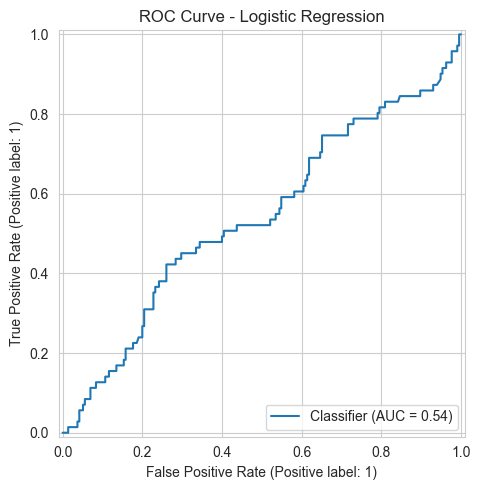

--- Coefficients and Odds Ratios ---


,Feature,Coefficient,Odds Ratio
0,danceability_%,-0.2531,0.7764
1,energy_%,-0.0267,0.9736


In [23]:
exec(nb.cells[25].source)

### Kết luận phân loại Hit/Non-Hit

Mô hình Logistic Regression được xây dựng nhằm đánh giá khả năng của các đặc tính âm nhạc (danceability và energy) trong việc phân biệt bài hát Hit và Non-Hit. Kết quả cho thấy mô hình chỉ đạt Accuracy = 56.64% và ROC-AUC = 0.5401. Trong bối cảnh dữ liệu mất cân bằng, chỉ số ROC-AUC tiệm cận mức 0.5 là minh chứng cho thấy khả năng phân loại của mô hình gần như không khác biệt so với việc lựa chọn ngẫu nhiên.

Các chỉ số đánh giá cho thấy danceability và energy không cung cấp đủ tín hiệu thông tin để nhận diện chính xác những bài hát thành công trên Spotify. Đặc biệt, độ chính xác đối với nhóm Hit còn rất thấp (Precision = 0.29), phản ánh thực tế rằng có một lượng lớn bài hát sở hữu các chỉ số âm thanh rất cao nhưng lượt stream thực tế lại không đạt mức tương ứng, tạo ra các điểm nhiễu lớn trong tập dữ liệu.

Kết quả này nhất quán với mô hình OLS trước đó khi khả năng giải thích biến động của lượt stream gần như bằng không (Adjusted R² ≈ 0.003). Điều đó chứng minh sự thất bại của OLS không đơn thuần xuất phát từ việc vi phạm giả định tuyến tính, mà hệ quả trực tiếp từ việc hai biến độc lập chứa quá ít giá trị dự báo.

Nhìn chung, thành công thương mại của một ca khúc trên Spotify chịu ảnh hưởng quyết định từ các yếu tố phi âm nhạc (nằm ngoài phạm vi của Audio Features) như độ nổi tiếng của nghệ sĩ, hiệu ứng lan truyền mạng xã hội, thuật toán phân phối playlist và các chiến dịch marketing.

### Business Insight & Conclusion

Từ các kiểm định thống kê và mô hình hồi quy, ta không tìm thấy bằng chứng đủ mạnh để khẳng định rằng `danceability` và `energy` là những yếu tố quyết định lượng stream của bài hát trên Spotify.

Mặc dù các audio features phản ánh đặc điểm âm nhạc của bài hát, chúng dường như chỉ đóng vai trò nhỏ trong việc giải thích sự phổ biến của một ca khúc.

Kết quả này cho thấy thành công trên Spotify là một hiện tượng đa chiều, chịu ảnh hưởng bởi nhiều yếu tố ngoài nội dung âm thanh. Vì vậy, các nhà phân tích hoặc nhà sản xuất âm nhạc không nên chỉ dựa vào các audio features để dự đoán mức độ thành công của bài hát, mà cần kết hợp thêm các yếu tố về nghệ sĩ, marketing và hành vi người nghe.

## 5 Kết luận và Giải thích kết quả (Conclusion and Discussion)

### Trả lời câu hỏi nghiên cứu

**Giả thuyết thuận chiều (H₁) là *Sai* trên tập dữ liệu Spotify 2023 này.**

Cụ thể:
- `energy_%` **không** có bằng chứng thống kê cho tác động thuận chiều lên `log_streams`.
- `danceability_%` có liên quan thống kê nhưng theo hướng **nghịch** (hệ số âm), trái với kỳ vọng "bài dễ nhảy sẽ nghe nhiều hơn".
- Mô hình OLS giải thích dưới 1% biến thiên của lượt stream → audio features alone **không đủ** để mô tả thành công thương mại.

### Góc nhìn thực tế — Tại sao lại như vậy?

Một số giải thích hợp lý:

1. **Thành công stream phụ thuộc nhiều yếu tố ngoài âm nhạc:** danh tiếng nghệ sĩ, chiến dịch marketing, playlist editorial, TikTok viral, v.v.
2. **Tập dữ liệu đã là top hits 2023:** phạm vi danceability/energy bị thu hẹp; các bài trong chart vốn đã "đủ tốt" về mặt kỹ thuật, nên khó thấy gradient rõ giữa 70% và 90% energy.
3. **Xu hướng nghe nhạc đa dạng:** năm 2023 có cả pop sôi động lẫn ballad/hip-hop chill; không có một "công thức âm thanh" duy nhất cho hit.
4. **Hệ số âm của danceability** có thể phản ánh confounding (ví dụ một số thể loại ít danceable nhưng có fanbase lớn) — cần thêm biến kiểm soát để khẳng định nhân quả.

### Hạn chế của nghiên cứu

- Chỉ một năm (2023), một nguồn (Spotify top songs) → khó generalize.
- Chưa kiểm soát nghệ sĩ, thể loại, thời điểm phát hành, playlist reach.
- OLS giả định quan hệ tuyến tính; sai số không chuẩn (Jarque-Bera) → suy luận inferential cần thận trọng.
- Tương quan/hồi quy **không đồng nghĩa nhân quả**.


## 6 Ý nghĩa thực tiễn (Insights)

Dù H₁ không được ủng hộ, kết quả vẫn có giá trị thực tiễn:

- **Nghệ sĩ và producer:** Không nên coi danceability/energy cao là "công thức chắc thắng" cho lượt stream; chất lượng bài hát, branding và phân phối quan trọng hơn.
- **A&R / label:** Cần kết hợp audio features với dữ liệu marketing, social buzz và lịch sử nghệ sĩ khi đánh giá tiềm năng hit.
- **Nền tảng streaming:** Recommendation nên ưu tiên nhiều tín hiệu hành vi (skip rate, save, playlist add) thay vì chỉ dựa vào metadata âm nhạc.
- **Hướng mở rộng:** Thêm biến kiểm soát (artist popularity, genre, playlist counts), thử mô hình phi tuyến hoặc regularized regression để cải thiện giải thích và giảm bias.
